## Gaussian Blur with Manual filter, torch and CV

In [2]:
import cv2
import torch
import matplotlib.pyplot as plt

- Here i have avoided the border pixels in the range loop as this is without any padding 

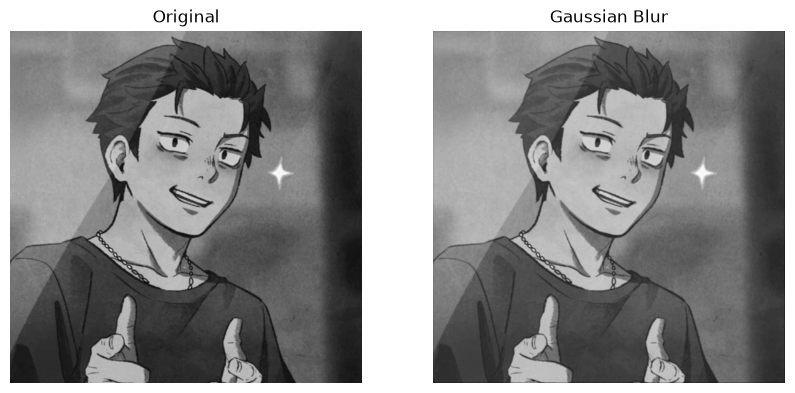

In [9]:
from torch import from_numpy
from cv2 import COLOR_BGR2RGB
b = cv2.imread('/home/aryan/code/Computer_vision/Media/img3.webp')
gaus = torch.tensor([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=torch.float32) / 16


img = cv2.cvtColor(b ,cv2.COLOR_BGR2GRAY)
img = torch.tensor(img, dtype=torch.float32)
x, y = img.shape

blurred = torch.zeros_like(img)

for i in range(1,x-1):
    for j in range(1,y-1):
        region = img[i-1:i+2, j-1:j+2]
        result = (region * gaus).sum()
        blurred[i,j] = result



plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap='gray')
plt.title("Gaussian Blur")
plt.axis('off')

plt.show()

In [4]:
blurred.shape


torch.Size([1440, 1440])